---
title: "Niveau de vie & participation électorale"
author: "Victoire Peltier"
format:
  revealjs:
    theme: solarized
    transition: none
    slide-number: false
    code-fold: true
    self-contained: true
---

## Objectifs

Ce travail vise à étudier la corrélation entre les revenus d'une population (échelle de la commune) et son taux de participation électorale.

## Méthode

Pour ce faire, on procèdera en plusieurs étapes :


- Une **ACP**, pour déterminer des variables représentatives de la richesse d'un territoire


- Une **analyse critique** du lien observé entre variables et participation électorale


- La construction d'un **modèle d'apprentissage automatique** afin de vérifier les résultats obtenus


- Un **clustering**, pour regrouper les territoires semblables sur ces critères.

# ACP

## Manipulation des jeux de données

Le jeu de données general_results donne des informations sur la participation électorale de chaque échelon territorial.

Nous commençons par **retirer les variables** qui ne nous intéressent pas pour cette étude, et  gardons uniquement le code de la commune et la participation électorale associée.

In [4]:
import pandas as pd
from pathlib import Path

filepath = "./sample_data/general_results.csv"
path = Path(filepath)

sep = ";"
df = pd.read_csv(path, sep=sep, dtype=str)

target_cols = ["code_commune", "ratio_votants_inscrits"]

df_filtered = df[target_cols]
output_path = path.parent / f"{path.stem}_filtered{path.suffix}"
df_filtered.to_csv(output_path, sep=sep, index=False)

## Vérification du résultat obtenu

Premières lignes :

In [5]:
df_filtered.head(3)

,code_commune,ratio_votants_inscrits
0,01160,42.5
1,01160,40.71
2,01160,37.33


In [6]:
df_filtered.shape

(3162440, 2)

## Deuxième jeu
Le deuxième jeu de données utilisé contient des informations sur les revenus déclarés par les citoyen.nes français.es.


On déduit le code de la commune à partir du code IRIS, afin de faire la jointure entre les deux jeux de données dans un second temps.


Il est aussi nécessaire de **fusionner certaines lignes** : deux données ayant le même code communal doivent être regroupées, même si elles n'ont pas le même IRIS

In [7]:
filepath = "./sample_data/BASE_TD_FILO_DISP_IRIS_2018.csv"
path = Path(filepath)

df_rev = pd.read_csv(path, sep=";", dtype=str)

df_rev["id_commune"] = df_rev["IRIS"].str[:5]

cols_num = [c for c in df_rev.columns if c not in ["IRIS", "id_commune"]]
df_rev[cols_num] = df_rev[cols_num].apply(pd.to_numeric, errors="coerce")

df_commune = df_rev.groupby("id_commune")[cols_num].mean().reset_index()

output_path = path.parent / f"{path.stem}_commune.csv"
df_commune.to_csv(output_path, sep=";", index=False)
#print(f"Fichier sauvegardé : {output_path} ({len(df_commune)} lignes, {len(df_commune.columns)} colonnes)")

## Jointure
On réalise la **jointure** entre les deux jeux de données : on obtient la participation et les données sur les revenus pour chaque commune.

In [8]:
df_participation = pd.read_csv("./sample_data/general_results_filtered.csv", sep=";", dtype=str)
df_revenus = pd.read_csv("./sample_data/BASE_TD_FILO_DISP_IRIS_2018_commune.csv", sep=";", dtype=str)

df_merged = df_participation.merge(
    df_revenus,
    left_on="code_commune",
    right_on="id_commune",
    how="inner"
).drop(columns="id_commune")

df_merged.to_csv("./sample_data/merged.csv", sep=";", index=False)
#print(f"Fichier sauvegardé : {len(df_merged)} lignes, {len(df_merged.columns)} colonnes")

## Premières représentations graphiques

On trace une première carte : la participation en fonction du département.

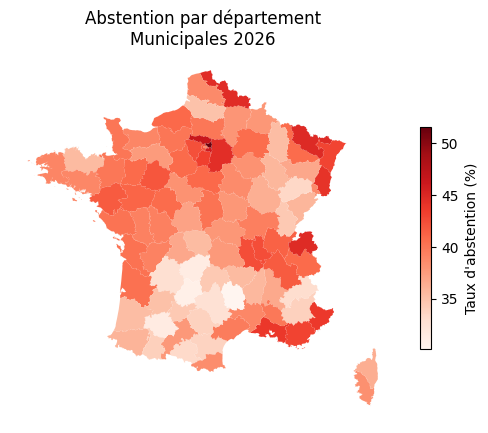

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
gdf = gpd.read_file(url)
gdf = gdf.rename(columns={"code": "code_dept"})

df_base = pd.read_csv("./sample_data/general_results.csv", sep=";", dtype=str)

df_dept_abs = df_base.copy()
df_dept_abs["code_dept"] = df_dept_abs["code_commune"].str[:2]
df_dept_abs["ratio_abstentions_inscrits"] = df_dept_abs["ratio_abstentions_inscrits"].astype(float)
df_dept_abs = df_dept_abs.groupby("code_dept")["ratio_abstentions_inscrits"].mean().reset_index()

gdf_abs = gdf.merge(df_dept_abs, on="code_dept", how="left")

gdf_abs.plot(
    column="ratio_abstentions_inscrits", cmap="Reds", legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Taux d'abstention (%)", "shrink": 0.6}
)
plt.title("Abstention par département\nMunicipales 2026")
plt.axis("off")
plt.show()

## Valeurs manquantes
Observons le ratio de valeurs manquantes :

In [10]:
abst = pd.DataFrame({
    "nb_na": df.isna().sum(),
    "pct_na": df.isna().mean() * 100
})

abst.sort_values("pct_na", ascending=False).head(5)

,nb_na,pct_na
libelle_canton,2907605,91.941823
code_canton,2641176,83.517031
libelle_circonscription,2607546,82.453612
code_circonscription,2341117,74.028820
ratio_blancs_votants,1895524,59.938655


## Valeurs manquantes
Les variables qui ont un fort taux de valeurs manquantes ne sont pas cruciales pour notre études. Nous choisissons tout de même de les imputer.

In [11]:
from sklearn.impute import SimpleImputer

cols_num = df_merged.drop(columns="code_commune").columns
imputer = SimpleImputer(strategy="median")
df_imputed = df_merged.copy()
df_imputed[cols_num] = imputer.fit_transform(df_merged[cols_num].astype(float))

## Standardisation et détermination des composantes

On réalise la PCA, précédée par une standardisation des données.

PC1 : 57.2%  (cumulé : 57.2%)
PC2 : 17.8%  (cumulé : 75.0%)
PC3 : 10.4%  (cumulé : 85.4%)
PC4 : 3.4%  (cumulé : 88.7%)
PC5 : 3.3%  (cumulé : 92.0%)


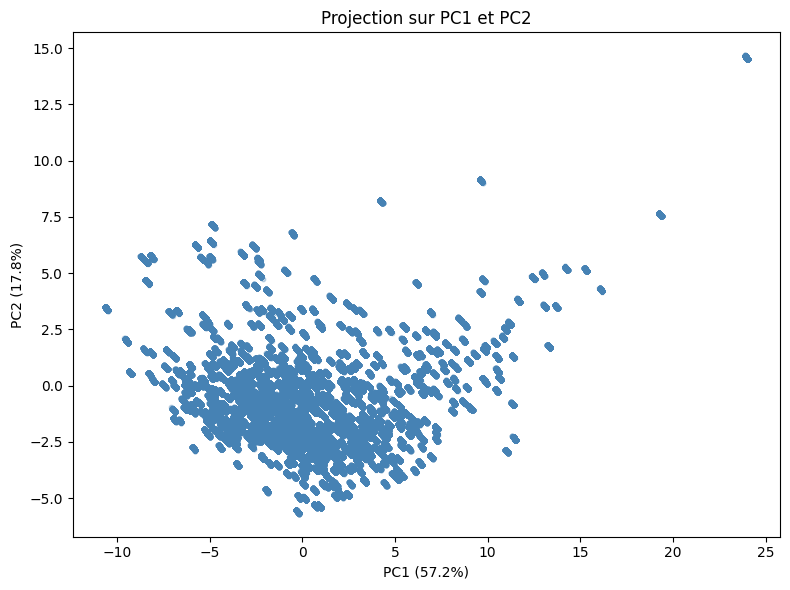

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardisation
cols_num = df_imputed.drop(columns="code_commune").columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed[cols_num].astype(float))

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcul de la variance expliquée
variance_expliquee = pca.explained_variance_ratio_
for i, v in enumerate(variance_expliquee[:5], 1):
    print(f"PC{i} : {v*100:.1f}%  (cumulé : {variance_expliquee[:i].sum()*100:.1f}%)")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10, color="steelblue")
plt.xlabel(f"PC1 ({variance_expliquee[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({variance_expliquee[1]*100:.1f}%)")
plt.title("Projection sur PC1 et PC2")
plt.tight_layout()
plt.show()

## Commentaire sur les composantes principales

## PC1
Score de 57.2%. On observe un axe dominant très fort. Plus de la moitié des informations est concentrée sur une seule dimension. En effet, comme les variables de revenus sont toutes très corrélées entre elles (déciles D1 à D9, médiane, etc.), PC1 capte essentiellement le niveau de vie général de la commune.



## PC2
Score de 17.8%. Deuxième axe significatif, qui capte probablement les inégalités internes à la commune (écart entre les bas et hauts revenus indépendamment du niveau moyen). Une commune peut être riche en moyenne mais très inégalitaire, ou modeste mais homogène.


## PC3
Score de 10.4%. Encore non négligeable, peut-être lié à des variables spécifiques comme DISP_TP6018 (taux de pauvreté) qui peut diverger du niveau médian dans certaines configurations territoriales.


## PC4, PC5
Scores de 3.4% et 3.3% : chute brutale. Ces composantes captent vraisemblablement du bruit ou des spécificités très locales.

## Chiffres sur les composantes

In [13]:
eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_

table_pca = pd.DataFrame({
    "Valeur propre": eigenvalues,
    "Variance expliquée (%)": variance_ratio * 100,
    "Inertie cumulée (%)": variance_ratio.cumsum() * 100
}, index=[f"PC{i+1}" for i in range(len(eigenvalues))])

table_pca.round(6).head(5)

,Valeur propre,Variance expliquée (%),Inertie cumulée (%)
PC1,16.575353,57.156326,57.156326
PC2,5.167592,17.819262,74.975588
PC3,3.010049,10.379467,85.355055
PC4,0.982642,3.388418,88.743473
PC5,0.957616,3.302122,92.045594


## Cercle des corrélations

On trace ensuite le cercle des corrélations pour interpréter les composantes principales obtenues :

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def correlation_circle_matplotlib(pca, feature_names, min_contrib=0.15):

    pcs = pca.components_
    var_exp = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(7,7))

    # Cercle unité
    circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
    ax.add_artist(circle)

    # Axes
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

    # Flèches
    for i, feature in enumerate(feature_names):
        x = pcs[0, i]
        y = pcs[1, i]

        contrib = x**2 + y**2
        if contrib < min_contrib:
            continue

        ax.arrow(0, 0, x, y,
                 head_width=0.03,
                 head_length=0.03,
                 fc='black', ec='black')

        ax.text(x*1.1, y*1.1, feature, fontsize=12)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.2f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.2f}%)")

    ax.set_title("Cercle des corrélations")
    ax.set_aspect('equal')

    plt.grid(True)
    plt.show()


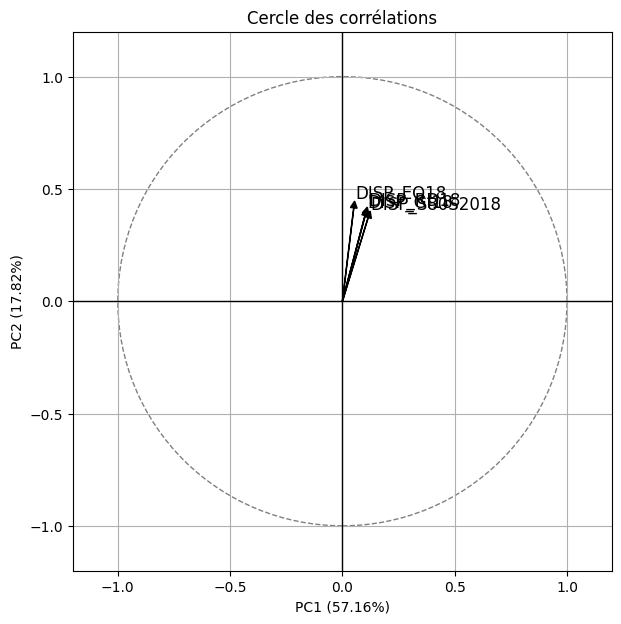

In [16]:
correlation_circle_matplotlib(pca, feature_names=cols_num.tolist())

## Corrélation des variables avec les axes

In [17]:
import pandas as pd

# DataFrame des loadings (corrélations variables / axes)
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols_num,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Contribution au premier axe (carré des corrélations)
contrib_pc1 = (loadings["PC1"] ** 2).sort_values(ascending=False)
print("Top variables — PC1 :")
print(contrib_pc1.head(4))

# Contribution au deuxième axe
contrib_pc2 = (loadings["PC2"] ** 2).sort_values(ascending=False)
print("\nTop variables — PC2 :")
print(contrib_pc2.head(4))

Top variables — PC1 :
DISP_MED18    0.059055
DISP_D618     0.058721
DISP_D418     0.058515
DISP_D718     0.057566
Name: PC1, dtype: float64

Top variables — PC2 :
DISP_EQ18        0.172825
DISP_RD18        0.152087
DISP_GI18        0.145380
DISP_S80S2018    0.138891
Name: PC2, dtype: float64


## Variables significatives - composante n°1


DISP_MED18 est la médiane du revenu disponible par unité de consommation (en euros). C'est cette variable qui est la plus représentative des revenus d'une commune.

Les différentes DISP_DX représentent les déciles du revenu disponible par unité de consommation (en euros).

PC1 est une composante résolument tournée vers une moyenne de revenus pour une commune.

## Variables significatives - composante n°2

DISP_EQ18 est l'écart inter-quartile rapporté à la médiane : comme pressenti plus tôt, la seconde composante représente davantage les écarts de revenus au sein d'une commune.

## Nouvelle ACP
Il est judicieux de refaire l'ACP sans les résultats extraits de general_results.
On extrait la corrélation entre composantes principales extraites et participation :

In [18]:
# ACP uniquement sur les variables de revenus
cols_revenus = [c for c in cols_num if c != "ratio_votants_inscrits"]
X_revenus = scaler.fit_transform(df_imputed[cols_revenus].astype(float))
pca_revenus = PCA()
X_pca_revenus = pca_revenus.fit_transform(X_revenus)

# Corrélation de la participation avec les axes obtenus
participation = df_imputed["ratio_votants_inscrits"].astype(float)
for i in range(3):
    corr = participation.corr(pd.Series(X_pca_revenus[:, i]))
    print(f"Corrélation participation / PC{i+1} : {corr:.3f}")

Corrélation participation / PC1 : 0.162
Corrélation participation / PC2 : -0.075
Corrélation participation / PC3 : -0.094


## Analyse critique des résultats obtenus

Les corrélations sont très faibles : 0.16 au maximum sur PC1. Ça veut dire que les revenus et inégalités seuls expliquent peu la participation électorale dans les données.

Plusieurs interprétations sont possibles :

## Raison n°1
La participation aux municipales 2026 n'est tout simplement pas fortement liée au niveau de vie communal. D'autres facteurs (taille de la commune, compétitivité du scrutin, présence de listes, rural/urbain) jouent probablement un rôle plus important.

## Raison n°2
Le niveau d'agrégation masque les effets : travailler à l'échelle communale, avec des moyennes, a trop flouté les données. Les effets socio-économiques sur la participation sont souvent plus visibles à l'échelle individuelle ou infra-communale (IRIS justement). L'agrégation lisse les disparités.


## Raison n°3
Les données de revenus datent de 2018, et on croise des revenus 2018 avec des élections 2026. En huit ans, les dynamiques territoriales ont pu évoluer significativement.

# Apprentissage automatique

## Raisonnement

On souhaite vérifier que les variables sélectionnées sont effectivement inefficaces pour prédire la participation d'une commune.

Pour ce faire, on crée un modèle de régression. S'il est bon pour prédire des valeurs de participation, alors peut-être que les variables y sont finalement corrélées.

R²  : 0.050
MAE : 13.038


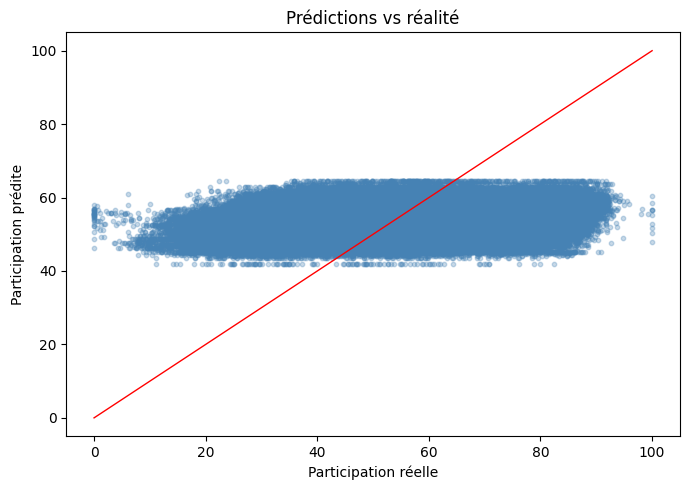

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Features et cible
X = df_imputed[cols_revenus].astype(float)
y = df_imputed["ratio_votants_inscrits"].astype(float)

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Évaluation
y_pred = model.predict(X_test_scaled)
print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.3f}")

# Visualisation prédictions vs réalité
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=1)
plt.xlabel("Participation réelle")
plt.ylabel("Participation prédite")
plt.title("Prédictions vs réalité")
plt.tight_layout()
plt.show()

## Interprétation de la partie ML

**R**² = 0.05 : le résultat est clair, les variables de revenus n'expliquent que 5% de la variance de la participation. Le modèle est inutilisable en pratique.


De même, le **MAE** = 13 est très parlant : le modèle se trompe en moyenne de 13 points de participation. C'est énorme pour une variable qui varie typiquement entre 20% et 80%.

## Conclusion ML

Le niveau de vie et les inégalités communales ne déterminent pas la participation électorale aux municipales 2026, du moins pas à cette échelle d'analyse et avec ces données. C'est en soi un résultat intéressant à documenter.

## Cartes
On peut tracer les deux cartes en vis-à-vis afin de se persuader de ce résultat :

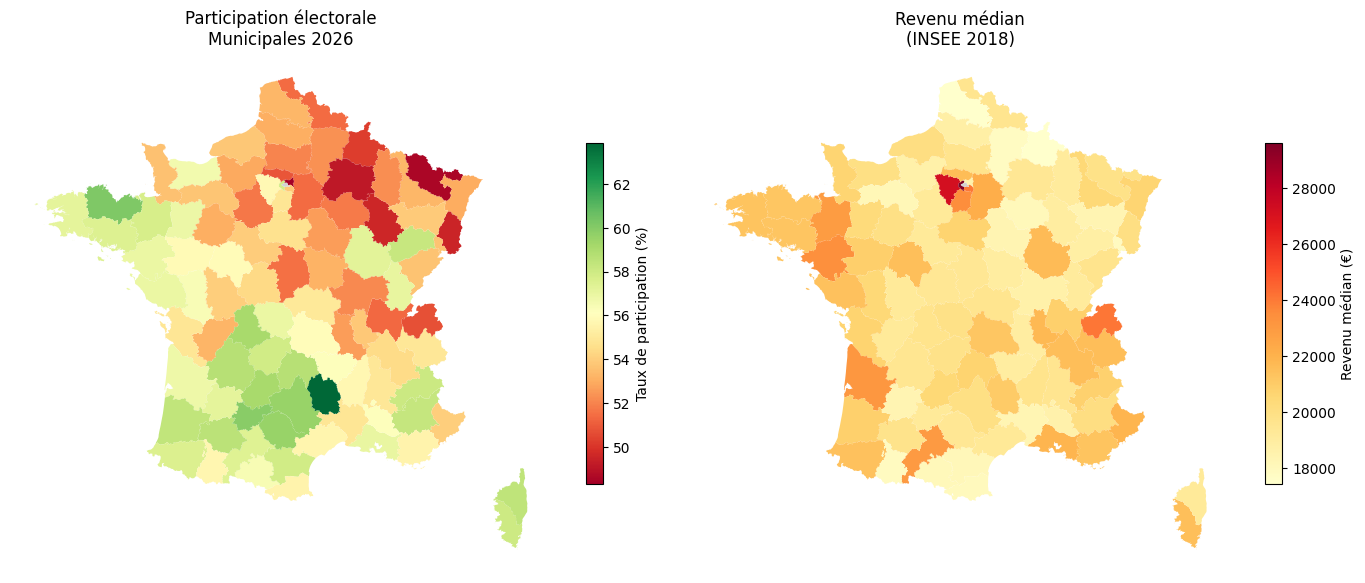

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
gdf = gpd.read_file(url)
gdf = gdf.rename(columns={"code": "code_dept"})

# Agréger nos données à l'échelle départementale
df_dept = df_imputed.copy()
df_dept["code_dept"] = df_dept["code_commune"].str[:2]
df_dept = df_dept.groupby("code_dept")[["ratio_votants_inscrits", "DISP_MED18"]].mean().reset_index()
df_dept[["ratio_votants_inscrits", "DISP_MED18"]] = df_dept[["ratio_votants_inscrits", "DISP_MED18"]].astype(float)

gdf_merged = gdf.merge(df_dept, on="code_dept", how="left")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gdf_merged.plot(
    column="ratio_votants_inscrits", ax=axes[0], cmap="RdYlGn", legend=True,
    missing_kwds={"color": "lightgrey", "label": "Données manquantes"},
    legend_kwds={"label": "Taux de participation (%)", "shrink": 0.6}
)
axes[0].set_title("Participation électorale\nMunicipales 2026")
axes[0].axis("off")

gdf_merged.plot(
    column="DISP_MED18", ax=axes[1], cmap="YlOrRd", legend=True,
    missing_kwds={"color": "lightgrey", "label": "Données manquantes"},
    legend_kwds={"label": "Revenu médian (€)", "shrink": 0.6}
)
axes[1].set_title("Revenu médian\n(INSEE 2018)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Résidu

Le résidu est l'écart entre participation prédite et réelle.

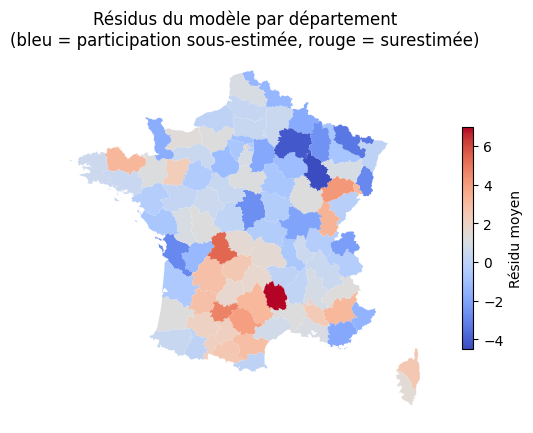

In [21]:
df_residus = df_imputed.copy()
X_all = scaler.transform(df_residus[cols_revenus].astype(float))
df_residus["residus"] = df_residus["ratio_votants_inscrits"].astype(float) - model.predict(X_all)

df_dept_res = df_residus.copy()
df_dept_res["code_dept"] = df_dept_res["code_commune"].str[:2]
df_dept_res = df_dept_res.groupby("code_dept")["residus"].mean().reset_index()

gdf_res = gdf.merge(df_dept_res, on="code_dept", how="left")

gdf_res.plot(
    column="residus", cmap="coolwarm", legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Résidu moyen", "shrink": 0.6}
)
plt.title("Résidus du modèle par département\n(bleu = participation sous-estimée, rouge = surestimée)")
plt.axis("off")
plt.show()

Il est intéressant de constater que la participation a été très surestimée dans la Lozère, et très sous estimée pour la Haute Marne.

# Clustering

## Objectif
On tente de regrouper des départements selon des tendances concernant le niveau de richesse et la participation.

## Algorithme K-Means

Avec autant de lignes, K-Means est le seul algorithme raisonnablement rapide.

Pour éviter le problème des variables de revenus très corrélées entre elles, on travaille sur les axes PCA (PC1 à PC3, qui capturent 85% de la variance), en plus de la participation.

## Détermination du coude et résultats

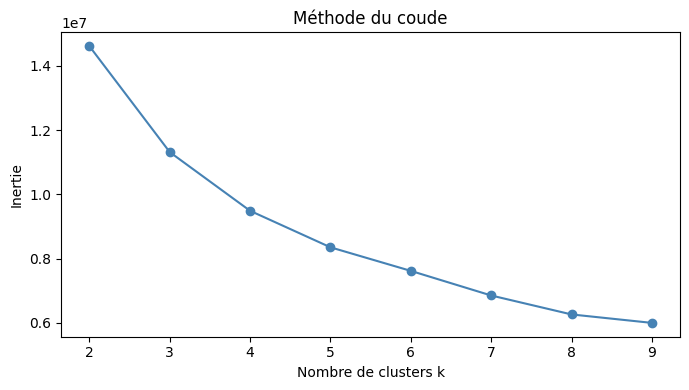

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np

cols_features = cols_revenus + ["ratio_votants_inscrits"]
X_cluster = df_imputed[cols_features].astype(float)

scaler_c = StandardScaler()
X_scaled_c = scaler_c.fit_transform(X_cluster)

pca_c = PCA(n_components=3)
X_pca_c = pca_c.fit_transform(X_scaled_c[:, :-1])
participation_scaled = X_scaled_c[:, -1].reshape(-1, 1)
X_final = np.hstack([X_pca_c, participation_scaled])

inertias = []
ks = range(2, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_final)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker="o", color="steelblue")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.tight_layout()
plt.show()

In [23]:
k_optimal = 4

km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init="auto")
df_imputed["cluster"] = km_final.fit_predict(X_final)

profil = df_imputed.groupby("cluster")[["ratio_votants_inscrits"] + list(cols_revenus[:3])].mean()
print(profil.round(2))

         ratio_votants_inscrits  DISP_TP6018  DISP_Q118  DISP_MED18
cluster                                                            
0                         48.54        33.10   12167.93    16822.38
1                         56.65        13.74   17776.64    23861.67
2                         59.11        12.14   21856.83    31486.25
3                         53.98        21.78   14676.29    19904.61


## Cluster 0 : communes précaires, forte abstention

Participation la plus basse, taux de pauvreté très élevé, revenus les plus faibles.
Typiquement des grandes banlieues populaires ou des territoires désindustrialisés.


## Cluster 1 : communes intermédiaires, bonne participation

Participation correcte, pauvreté modérée, revenus moyens.
Profil périurbain ou petites villes équilibrées.


## Cluster 2 : communes aisées, participation élevée

Participation la plus haute, pauvreté la plus faible, revenus les plus élevés.
Typiquement des communes résidentielles riches.

## Cluster 3 : communes modestes, abstention intermédiaire

Participation faible, pauvreté notable, revenus bas.

## Représentation graphique des clusters

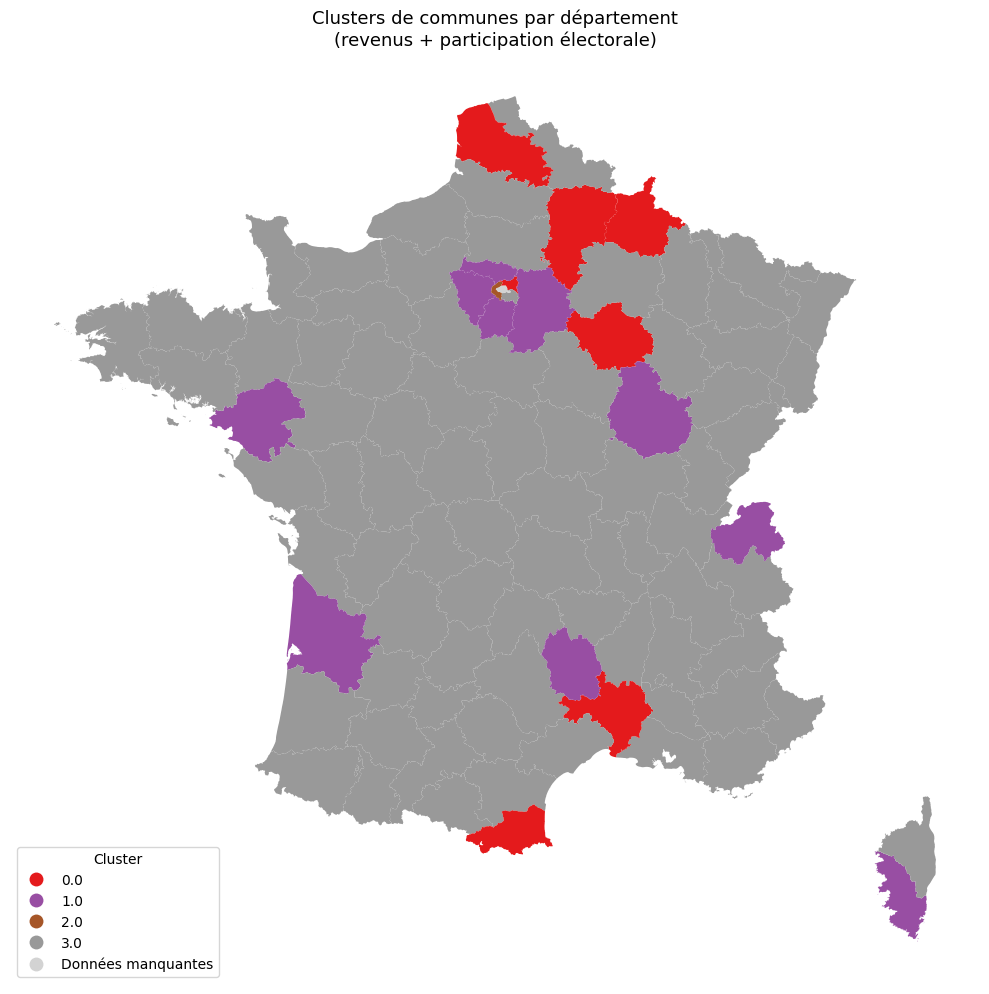

In [24]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
gdf = gpd.read_file(url)
gdf = gdf.rename(columns={"code": "code_dept"})

# Cluster majoritaire par département
df_imputed["code_dept"] = df_imputed["code_commune"].str[:2]
df_dept_cluster = (
    df_imputed.groupby("code_dept")["cluster"]
    .agg(lambda x: x.value_counts().idxmax())  # cluster dominant
    .reset_index()
)

gdf_map = gdf.merge(df_dept_cluster, on="code_dept", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
gdf_map.plot(
    column="cluster", ax=ax,
    cmap="Set1", legend=True, categorical=True,
    missing_kwds={"color": "lightgrey", "label": "Données manquantes"},
    legend_kwds={"title": "Cluster", "loc": "lower left"}
)
ax.set_title("Clusters de communes par département\n(revenus + participation électorale)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

# Conclusion

En conclusion, notre étude tend à démontrer que **le niveau de vie d'une commune n'est pas suffisant pour déterminer sa participation électorale**.
Par conséquent, les variables sélectionnées ne suffisent pas à entraîner un bon modèle.
Néanmoins, des tendances peuvent être repérées sous forme de **clusters**.